In [1]:
import os
import json
import math
import random
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

from net.st_gcn import Model

In [2]:
DSET_PATH = "/Users/steventan/.cache/kagglehub/datasets/soumicksarker/ipn-hand-dataset/versions/7"
TRAIN_PATH = os.path.join(DSET_PATH, "train_skeletons")
TEST_PATH = os.path.join(DSET_PATH, "test_skeletons")

def load_skel_data(path):
    skeletons = torch.load(os.path.join(path, "skeletons_tensor.pt"))  
    with open(os.path.join(path, "skeleton_annots.json"), "r") as f:
        metadata = json.load(f)
    return skeletons, metadata

def reshape_skel_for_stgcn(skels):
    return skels.permute(0, 3, 1, 2).unsqueeze(-1)

train_skels, train_metadata = load_skel_data(TRAIN_PATH)
test_skels, test_metadata = load_skel_data(TEST_PATH)

# reshape skeleton data for the format used by st-gcn paper
train_skels = reshape_skel_for_stgcn(train_skels)
test_skels = reshape_skel_for_stgcn(test_skels)

# minus one to make 0-indexed
train_labels = torch.tensor(
    [sample["label_id"] - 1 for sample in train_metadata["samples"]],
    dtype=torch.long,
)
test_labels = torch.tensor(
    [sample["label_id"] - 1 for sample in test_metadata["samples"]],
    dtype=torch.long,
)


# filter out first 100 training datapoints since they aren't labelled well
train_skels = train_skels[100:]
train_labels = train_labels[100:]

num_classes = len(torch.unique(train_labels))

# sanity check stuff
print("Labels shape:", train_labels.shape)
print("Skeletons shape:", train_skels.shape)
print("Num classes:", num_classes)

Labels shape: torch.Size([3781])
Skeletons shape: torch.Size([3781, 3, 210, 21, 1])
Num classes: 14


/var/folders/_1/ph20kymj4s9bnnn49x3mjlxr0000gn/T/ipykernel_18431/1268182783.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  skeletons = torch.load(os.path.join(path, "sk

In [3]:
# Set device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [4]:
train_ds = TensorDataset(train_skels, train_labels)
test_ds = TensorDataset(test_skels, test_labels)

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print("Train samples:", len(train_ds))
print("Test samples:", len(test_ds))

Train samples: 3781
Test samples: 1556


In [5]:
def augment_skeleton_sequence(seq: torch.Tensor,
                              scale_min=0.8, scale_max=1.2,
                              translate_min=-0.1, translate_max=0.1,
                              jitter_sigma=0.001,
                              jitter_smooth=0.9):
    """
    Augmentation for fixed-camera hand gesture skeletons.
    
    seq: Tensor (C, T, V) => (# channels, # frames, # joints)
    - Applies one global scale + translation to all frames (consistent camera)
    - Adds temporally-smoothed jitter (simulates detector noise)
    """

    C, T, V = seq.shape
    device = seq.device

    # Choose scale and translation
    scale = random.uniform(scale_min, scale_max)

    tx = random.uniform(translate_min, translate_max)
    ty = random.uniform(translate_min, translate_max)

    # Apply global affine transform
    seq_aug = seq.clone()
    seq_aug[:2, :, :] *= scale           # scale x, y
    seq_aug[0, :, :] += tx               # translate x
    seq_aug[1, :, :] += ty               # translate y

    # Smooth jitter
    if jitter_sigma > 0:
        # white noise base
        noise = torch.randn(C, T, V, device=device) * jitter_sigma

        # exponential smoothing along time dimension
        smooth = torch.zeros_like(noise)
        smooth[:, 0, :] = noise[:, 0, :]
        alpha = 1 - jitter_smooth  # smoothing factor

        for t in range(1, T):
            smooth[:, t, :] = jitter_smooth * smooth[:, t-1, :] + alpha * noise[:, t, :]

        # add jitter
        seq_aug += smooth

    return seq_aug

In [6]:
def run_epoch(loader, model, criterion, optimizer=None):
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for x_batch, y_batch in loader:    
        if optimizer is not None:
            # Training mode
            optimizer.zero_grad()

            '''
            # Apply augmentation per sample in the batch
            x_batch_aug = []
            for i in range(x_batch.shape[0]):
                x_aug = augment_skeleton_sequence(x_batch[i].squeeze(-1))
                x_batch_aug.append(x_aug)
            x_batch = torch.stack(x_batch_aug).unsqueeze(-1)
            '''

        x_batch = x_batch.to(device, dtype=torch.float32)
        y_batch = y_batch.to(device)
    
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
    
        if optimizer is not None:
            loss.backward()
            optimizer.step()
    
        total_loss += loss.item() * x_batch.size(0)
    
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)
    
    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc


def train_model(train_loader, test_loader, model, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_accs = []
    test_accs = []
    
    for epoch in tqdm(range(1, epochs + 1), desc="Epochs"):
        train_loss, train_acc = run_epoch(train_loader, model, criterion, optimizer)
        test_loss, test_acc = run_epoch(test_loader, model, criterion, optimizer=None)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f} | "
            f"test_loss={test_loss:.4f}, test_acc={test_acc:.3f}"
        )

    return train_accs, test_accs

def eval_model(model, test_loader):
    criterion = nn.CrossEntropyLoss()
    loss, acc = run_epoch(test_loader, model, criterion)
    print(f"Test Accuracy: {acc}")

In [7]:
model = Model(num_class=num_classes, graph_args={"strategy" : "distance"}, in_channels=3, edge_importance_weighting=False, dropout=0.5)
model = model.to(device)
train_accs, test_accs = train_model(train_loader, test_loader, model, epochs=30)

Epochs:   3%|██████▍                                                                                                                                                                                         | 1/30 [02:07<1:01:44, 127.75s/it]

Epoch 01 | train_loss=1.9626, train_acc=0.357 | test_loss=2.1182, test_acc=0.347


Epochs:   7%|████████████▉                                                                                                                                                                                     | 2/30 [04:16<59:52, 128.29s/it]

Epoch 02 | train_loss=1.8035, train_acc=0.397 | test_loss=1.9920, test_acc=0.384


Epochs:  10%|███████████████████▍                                                                                                                                                                              | 3/30 [06:24<57:41, 128.21s/it]

...

Epoch 28 | train_loss=0.3630, train_acc=0.867 | test_loss=0.9783, test_acc=0.778


Epochs:  97%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋      | 29/30 [1:01:56<02:08, 128.48s/it]

Epoch 29 | train_loss=0.3619, train_acc=0.873 | test_loss=0.9154, test_acc=0.801


Epochs: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [1:04:04<00:00, 128.16s/it]

Epoch 30 | train_loss=0.3469, train_acc=0.879 | test_loss=0.9056, test_acc=0.790


In [ ]:
# dist, dropout=0.5: train_acc=0.911, test_loss=0.810
# dist, dropout=0.5, temporal kernel=5: 
# spatial, dropout=0.5: test_acc=0.809

In [8]:
torch.save(model.state_dict(), "stgcn_dist_temp_5_dropout_0.5.pth")

In [12]:
model = Model(num_class=num_classes, graph_args={"strategy" : "distance"}, in_channels=3, edge_importance_weighting=False)
model.load_state_dict(torch.load("stgcn_dist_dropout_0.5.pth"))
model.to(device)
None

/var/folders/_1/ph20kymj4s9bnnn49x3mjlxr0000gn/T/ipykernel_18106/1823185538.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("stgcn_dist_

In [9]:
eval_model(model, test_loader)

Test Accuracy: 0.7898457583547558


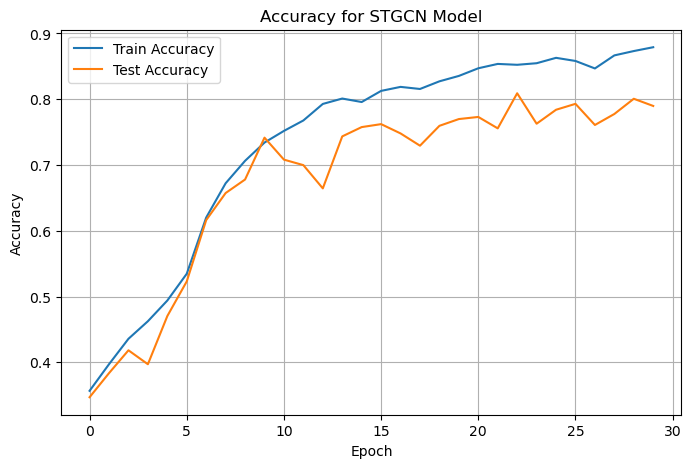

In [10]:
x = np.arange(30)
plt.figure(figsize=(8, 5))
plt.plot(x, train_accs, label='Train Accuracy')
plt.plot(x, test_accs, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy for STGCN Model')
plt.legend()
plt.grid(True)
plt.show()